# ZOIDBERG2.0 - Step 2: Preprocessing & Feature Engineering

**Project:** Medical Imaging / Computer Aided Diagnosis - Pneumonia Detection  
**Author:** ML Architecture Team  
**Date:** January 2026  

---

## Objectives

1. **Image Preprocessing Pipeline:**
   - Load and resize images to consistent dimensions
   - Normalize pixel values for model compatibility
   - Handle grayscale vs RGB images

2. **Data Augmentation:**
   - Rotation, shifts, zoom, flips
   - Preserve medical relevance (no extreme transformations)
   - Create augmented training dataset

3. **Feature Extraction:**
   - Raw pixel features (flattened)
   - Statistical features (mean, std, histogram)
   - Texture features (optional: HOG, GLCM)

4. **PCA Implementation:**
   - Fit on training data
   - Retain 95% variance
   - Visualize principal components

5. **Data Split Strategy:**
   - Train-test split (80/20) with stratification
   - 5-fold cross-validation setup
   - Keep Dataset3 separate for tuning

6. **Save Processed Data:**
   - Save preprocessed images
   - Save feature matrices
   - Save PCA transformers

---

In [1]:
# Import Required Libraries
import os
import sys
import warnings
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from tqdm import tqdm
import yaml

# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
import joblib

# Configuration
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Add src to path
project_root = Path.cwd().parent if 'notebooks' in str(Path.cwd()) else Path.cwd()
sys.path.insert(0, str(project_root / 'src'))

# Import custom modules
from data.data_loader import DatasetLoader
from utils.helpers import set_seed, save_model, Logger

print("✓ Libraries imported successfully")
print(f"✓ Project root: {project_root}")

✓ Libraries imported successfully
✓ Project root: c:\Users\MOULOUDIA\OneDrive - Epitech\Bureau\epitech\T-DEV-810-PAR_19


In [2]:
# Load Configuration
config_path = project_root / 'config' / 'config.yaml'

with open(config_path, 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

# Set random seed for reproducibility
set_seed(config['reproducibility']['seed'])

print("✓ Configuration loaded")
print(f"\nProject: {config['project']['name']} v{config['project']['version']}")
print(f"Random Seed: {config['reproducibility']['seed']}")
print(f"Target Image Size: {config['image']['target_size']}")
print(f"Color Mode: {config['image']['color_mode']}")

✓ Random seed set to 42
✓ Configuration loaded

Project: ZOIDBERG2.0 v2.0.0
Random Seed: 42
Target Image Size: [224, 224]
Color Mode: grayscale


In [3]:
# Initialize Logger
log_path = project_root / config['logging']['log_file']
logger = Logger(log_path)

logger.info("="*60)
logger.info("STEP 2: PREPROCESSING & FEATURE ENGINEERING")
logger.info("="*60)

[INFO] ============================================================
[INFO] STEP 2: PREPROCESSING & FEATURE ENGINEERING
[INFO] ============================================================


---
## 1. Load Datasets

Load all three datasets and get image paths with labels.

In [ ]:
# Initialize DatasetLoader
loader = DatasetLoader(str(config_path))

# Classification mode
multiclass_mode = True

# Get image paths and labels for each dataset
print("Loading dataset paths and labels...\n")
print(f"Multiclass mode: {multiclass_mode}")

# Dataset 1 (Training)
dataset1_paths, dataset1_labels = loader.get_image_paths_and_labels('dataset1', multiclass=multiclass_mode)
print(f"\nDataset1: {len(dataset1_paths)} images")
print(f"  Classes: {np.unique(dataset1_labels, return_counts=True)}")

# Dataset 2 (Validation)
dataset2_paths, dataset2_labels = loader.get_image_paths_and_labels('dataset2', multiclass=multiclass_mode)
print(f"\nDataset2: {len(dataset2_paths)} images")
print(f"  Classes: {np.unique(dataset2_labels, return_counts=True)}")

# Dataset 3 (Hyperparameter Tuning - Reserved)
dataset3_paths, dataset3_labels = loader.get_image_paths_and_labels('dataset3_tuning', multiclass=multiclass_mode)
print(f"\nDataset3 (Tuning): {len(dataset3_paths)} images")
print(f"  Classes: {np.unique(dataset3_labels, return_counts=True)}")

all_detected_classes = sorted(set(dataset1_labels) | set(dataset2_labels) | set(dataset3_labels))
print(f"\nDetected classes across all datasets: {all_detected_classes}")

logger.info(f"Multiclass mode: {multiclass_mode}")
logger.info(f"Loaded {len(dataset1_paths)} images from Dataset1")
logger.info(f"Loaded {len(dataset2_paths)} images from Dataset2")
logger.info(f"Loaded {len(dataset3_paths)} images from Dataset3 (reserved)")
logger.info(f"Detected classes: {all_detected_classes}")

Loading dataset paths and labels...

Multiclass mode: True

Dataset1: 5216 images
  Classes: (array(['BACTERIA', 'NORMAL', 'VIRUS'], dtype='<U8'), array([2530, 1341, 1345]))

Dataset2: 16 images
  Classes: (array(['BACTERIA', 'NORMAL'], dtype='<U8'), array([8, 8]))

Dataset3 (Tuning): 624 images
  Classes: (array(['BACTERIA', 'NORMAL', 'VIRUS'], dtype='<U8'), array([242, 234, 148]))

Detected classes across all datasets: ['BACTERIA', 'NORMAL', 'VIRUS']
[INFO] Multiclass mode: True
[INFO] Loaded 5216 images from Dataset1
[INFO] Loaded 16 images from Dataset2
[INFO] Loaded 624 images from Dataset3 (reserved)
[INFO] Detected classes: ['BACTERIA', 'NORMAL', 'VIRUS']


In [5]:
def summarize_labels(labels, dataset_name):
    unique, counts = np.unique(labels, return_counts=True)
    summary = dict(zip(unique, counts))
    
    print(f"\n{dataset_name} label summary:")
    for cls in ['NORMAL', 'BACTERIA', 'VIRUS']:
        print(f"  {cls}: {summary.get(cls, 0)}")
    
    return summary

dataset1_summary = summarize_labels(dataset1_labels, "Dataset1")
dataset2_summary = summarize_labels(dataset2_labels, "Dataset2")
dataset3_summary = summarize_labels(dataset3_labels, "Dataset3")


Dataset1 label summary:
  NORMAL: 1341
  BACTERIA: 2530
  VIRUS: 1345

Dataset2 label summary:
  NORMAL: 8
  BACTERIA: 8
  VIRUS: 0

Dataset3 label summary:
  NORMAL: 234
  BACTERIA: 242
  VIRUS: 148


---
## 2. Image Preprocessing Pipeline

Create a robust preprocessing pipeline for medical images.

In [6]:
def preprocess_image(image_path, target_size=(224, 224), color_mode='grayscale', normalize='standard'):
    """
    Preprocess a single medical image.
    
    Args:
        image_path (Path): Path to image file
        target_size (tuple): Target dimensions (width, height)
        color_mode (str): 'grayscale' or 'rgb'
        normalize (str): 'standard', 'minmax', or 'none'
    
    Returns:
        np.ndarray: Preprocessed image
    """
    try:
        # Load image
        img = Image.open(image_path)
        
        # Convert to appropriate color mode
        if color_mode == 'grayscale':
            img = img.convert('L')
        elif color_mode == 'rgb':
            img = img.convert('RGB')
        
        # Resize to target size
        img = img.resize(target_size, Image.LANCZOS)
        
        # Convert to numpy array
        img_array = np.array(img, dtype=np.float32)
        
        # Normalize
        if normalize == 'standard':
            # Zero mean, unit variance
            img_array = (img_array - np.mean(img_array)) / (np.std(img_array) + 1e-7)
        elif normalize == 'minmax':
            # Scale to [0, 1]
            img_array = (img_array - np.min(img_array)) / (np.max(img_array) - np.min(img_array) + 1e-7)
        
        return img_array
    
    except Exception as e:
        print(f"Error processing {image_path.name}: {e}")
        return None


def preprocess_dataset(image_paths, labels, target_size, color_mode, normalize='standard', max_samples=None):
    """
    Preprocess an entire dataset.
    
    Args:
        image_paths (list): List of image paths
        labels (list): List of labels
        target_size (tuple): Target image dimensions
        color_mode (str): Color mode
        normalize (str): Normalization method
        max_samples (int): Maximum samples to process (for testing)
    
    Returns:
        tuple: (processed_images, valid_labels)
    """
    if max_samples:
        image_paths = image_paths[:max_samples]
        labels = labels[:max_samples]
    
    processed_images = []
    valid_labels = []
    
    print(f"Preprocessing {len(image_paths)} images...")
    
    for img_path, label in tqdm(zip(image_paths, labels), total=len(image_paths)):
        img = preprocess_image(img_path, target_size, color_mode, normalize)
        
        if img is not None:
            processed_images.append(img)
            valid_labels.append(label)
    
    # Convert to numpy arrays
    X = np.array(processed_images)
    y = np.array(valid_labels)
    
    # Add channel dimension if grayscale
    if color_mode == 'grayscale' and len(X.shape) == 3:
        X = np.expand_dims(X, axis=-1)
    
    print(f"✓ Processed {len(X)} images successfully")
    print(f"  Shape: {X.shape}")
    print(f"  Dtype: {X.dtype}")
    print(f"  Value range: [{X.min():.3f}, {X.max():.3f}]")
    
    return X, y


print("✓ Preprocessing functions defined")

✓ Preprocessing functions defined


In [7]:
# Preprocess all datasets
target_size = tuple(config['image']['target_size'])
color_mode = config['image']['color_mode']
normalize = config['image']['normalization']

logger.info(f"Starting preprocessing: size={target_size}, mode={color_mode}, normalize={normalize}")

# Dataset 1
print("\n" + "="*60)
print("PREPROCESSING DATASET 1 (Training)")
print("="*60)
X_dataset1, y_dataset1 = preprocess_dataset(
    dataset1_paths, dataset1_labels, target_size, color_mode, normalize
)

# Dataset 2
print("\n" + "="*60)
print("PREPROCESSING DATASET 2 (Validation)")
print("="*60)
X_dataset2, y_dataset2 = preprocess_dataset(
    dataset2_paths, dataset2_labels, target_size, color_mode, normalize
)

# Dataset 3 (Reserved - we'll preprocess but keep separate)
print("\n" + "="*60)
print("PREPROCESSING DATASET 3 (Hyperparameter Tuning - Reserved)")
print("="*60)
X_dataset3, y_dataset3 = preprocess_dataset(
    dataset3_paths, dataset3_labels, target_size, color_mode, normalize
)

logger.info("All datasets preprocessed successfully")

[INFO] Starting preprocessing: size=(224, 224), mode=grayscale, normalize=standard

PREPROCESSING DATASET 1 (Training)
Preprocessing 5216 images...


100%|██████████| 5216/5216 [01:25<00:00, 61.02it/s]


✓ Processed 5216 images successfully
  Shape: (5216, 224, 224, 1)
  Dtype: float32
  Value range: [-6.846, 6.151]

PREPROCESSING DATASET 2 (Validation)
Preprocessing 16 images...


100%|██████████| 16/16 [00:00<00:00, 63.77it/s]


✓ Processed 16 images successfully
  Shape: (16, 224, 224, 1)
  Dtype: float32
  Value range: [-2.604, 3.016]

PREPROCESSING DATASET 3 (Hyperparameter Tuning - Reserved)
Preprocessing 624 images...


100%|██████████| 624/624 [00:09<00:00, 65.71it/s]

✓ Processed 624 images successfully
  Shape: (624, 224, 224, 1)
  Dtype: float32
  Value range: [-3.533, 5.194]
[INFO] All datasets preprocessed successfully


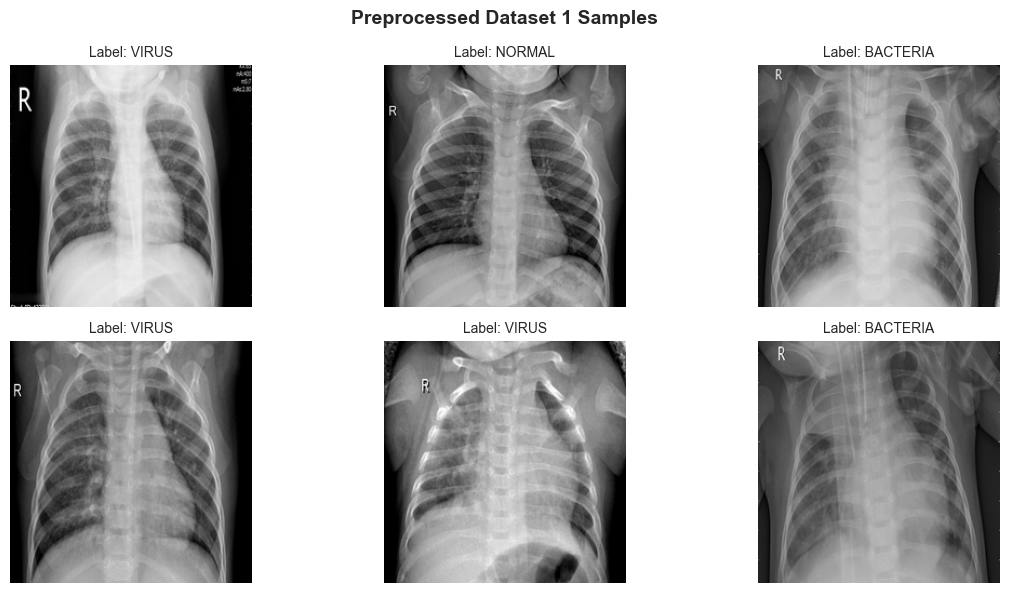

In [8]:
def visualize_preprocessed(X, y, n_samples=6, title="Preprocessed Images"):
    """
    Visualize preprocessed images.
    """
    n_samples = min(n_samples, len(X))
    n_rows = 2
    n_cols = int(np.ceil(n_samples / n_rows))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 6))
    axes = np.array(axes).flatten()
    
    indices = np.random.choice(len(X), n_samples, replace=False)
    
    for ax, idx in zip(axes, indices):
        img = X[idx]
        
        if img.shape[-1] == 1:
            img = img.squeeze()
        
        ax.imshow(img, cmap='gray' if len(img.shape) == 2 else None)
        ax.set_title(f"Label: {y[idx]}", fontsize=10)
        ax.axis('off')
    
    for ax in axes[n_samples:]:
        ax.axis('off')
    
    plt.suptitle(title, fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.show()

# Visualize samples from Dataset 1
visualize_preprocessed(X_dataset1, y_dataset1, n_samples=6, 
                       title="Preprocessed Dataset 1 Samples")

---
## 3. Feature Extraction

Extract features from preprocessed images for classical ML algorithms.

In [9]:
def extract_features(X, method='flatten'):
    """
    Extract features from preprocessed images.
    
    Args:
        X (np.ndarray): Preprocessed images (N, H, W, C)
        method (str): Feature extraction method
            - 'flatten': Flatten pixels into vector
            - 'statistical': Statistical features (mean, std, min, max, etc.)
            - 'hybrid': Combination of methods
    
    Returns:
        np.ndarray: Feature matrix (N, n_features)
    """
    n_samples = X.shape[0]
    
    if method == 'flatten':
        # Simply flatten each image
        features = X.reshape(n_samples, -1)
        print(f"Extracted flattened features: shape {features.shape}")
    
    elif method == 'statistical':
        # Extract statistical features
        features_list = []
        
        for img in X:
            feat = [
                np.mean(img),      # Mean intensity
                np.std(img),       # Standard deviation
                np.min(img),       # Minimum intensity
                np.max(img),       # Maximum intensity
                np.median(img),    # Median intensity
                np.percentile(img, 25),  # 25th percentile
                np.percentile(img, 75),  # 75th percentile
            ]
            features_list.append(feat)
        
        features = np.array(features_list)
        print(f"Extracted statistical features: shape {features.shape}")
    
    elif method == 'hybrid':
        # Combine flattened and statistical
        flat_features = X.reshape(n_samples, -1)
        
        stat_features_list = []
        for img in X:
            feat = [
                np.mean(img), np.std(img), np.min(img), np.max(img),
                np.median(img), np.percentile(img, 25), np.percentile(img, 75)
            ]
            stat_features_list.append(feat)
        
        stat_features = np.array(stat_features_list)
        features = np.concatenate([flat_features, stat_features], axis=1)
        print(f"Extracted hybrid features: shape {features.shape}")
    
    else:
        raise ValueError(f"Unknown method: {method}")
    
    return features


print("✓ Feature extraction functions defined")

✓ Feature extraction functions defined


In [10]:
# Extract features from all datasets
feature_method = 'flatten'  # Can change to 'statistical' or 'hybrid'

print(f"\nExtracting features using method: {feature_method}\n")
logger.info(f"Feature extraction method: {feature_method}")

X1_features = extract_features(X_dataset1, method=feature_method)
X2_features = extract_features(X_dataset2, method=feature_method)
X3_features = extract_features(X_dataset3, method=feature_method)

print(f"\n✓ Feature extraction complete")
print(f"  Dataset1: {X1_features.shape}")
print(f"  Dataset2: {X2_features.shape}")
print(f"  Dataset3: {X3_features.shape}")


Extracting features using method: flatten

[INFO] Feature extraction method: flatten
Extracted flattened features: shape (5216, 50176)
Extracted flattened features: shape (16, 50176)
Extracted flattened features: shape (624, 50176)

✓ Feature extraction complete
  Dataset1: (5216, 50176)
  Dataset2: (16, 50176)
  Dataset3: (624, 50176)


---
## 4. PCA for Dimensionality Reduction

Apply PCA to reduce dimensionality while retaining 95% of variance.

In [11]:
# Combine Dataset1 and Dataset2 for training
# (Dataset3 is reserved for hyperparameter tuning)
X_combined = np.vstack([X1_features, X2_features])
y_combined = np.concatenate([y_dataset1, y_dataset2])

print(f"Combined training data: {X_combined.shape}")
print(f"Class distribution: {np.unique(y_combined, return_counts=True)}")

combined_summary = dict(zip(*np.unique(y_combined, return_counts=True)))
print("\nCombined class summary:")
for cls in ['NORMAL', 'BACTERIA', 'VIRUS']:
    print(f"  {cls}: {combined_summary.get(cls, 0)}")

logger.info(f"Combined Dataset1 and Dataset2: {X_combined.shape}")

Combined training data: (5232, 50176)
Class distribution: (array(['BACTERIA', 'NORMAL', 'VIRUS'], dtype='<U8'), array([2538, 1349, 1345]))

Combined class summary:
  NORMAL: 1349
  BACTERIA: 2538
  VIRUS: 1345
[INFO] Combined Dataset1 and Dataset2: (5232, 50176)


In [12]:
# Apply PCA
pca_variance = config['features']['pca']['n_components']
pca_whiten = config['features']['pca']['whiten']

print(f"\nApplying PCA...")
print(f"  Target variance retention: {pca_variance*100:.1f}%")
print(f"  Whitening: {pca_whiten}")

# Fit PCA on combined training data
pca = PCA(n_components=pca_variance, whiten=pca_whiten, random_state=config['reproducibility']['seed'])
X_combined_pca = pca.fit_transform(X_combined)

# Transform Dataset3 separately
X3_pca = pca.transform(X3_features)

print(f"\n✓ PCA applied successfully")
print(f"  Original dimensions: {X_combined.shape[1]}")
print(f"  PCA dimensions: {X_combined_pca.shape[1]}")
print(f"  Variance explained: {pca.explained_variance_ratio_.sum()*100:.2f}%")
print(f"  Dimensionality reduction: {(1 - X_combined_pca.shape[1]/X_combined.shape[1])*100:.1f}%")

logger.info(f"PCA: {X_combined.shape[1]} -> {X_combined_pca.shape[1]} dimensions")
logger.info(f"Variance explained: {pca.explained_variance_ratio_.sum()*100:.2f}%")


Applying PCA...
  Target variance retention: 95.0%
  Whitening: True

✓ PCA applied successfully
  Original dimensions: 50176
  PCA dimensions: 792
  Variance explained: 95.01%
  Dimensionality reduction: 98.4%
[INFO] PCA: 50176 -> 792 dimensions
[INFO] Variance explained: 95.01%


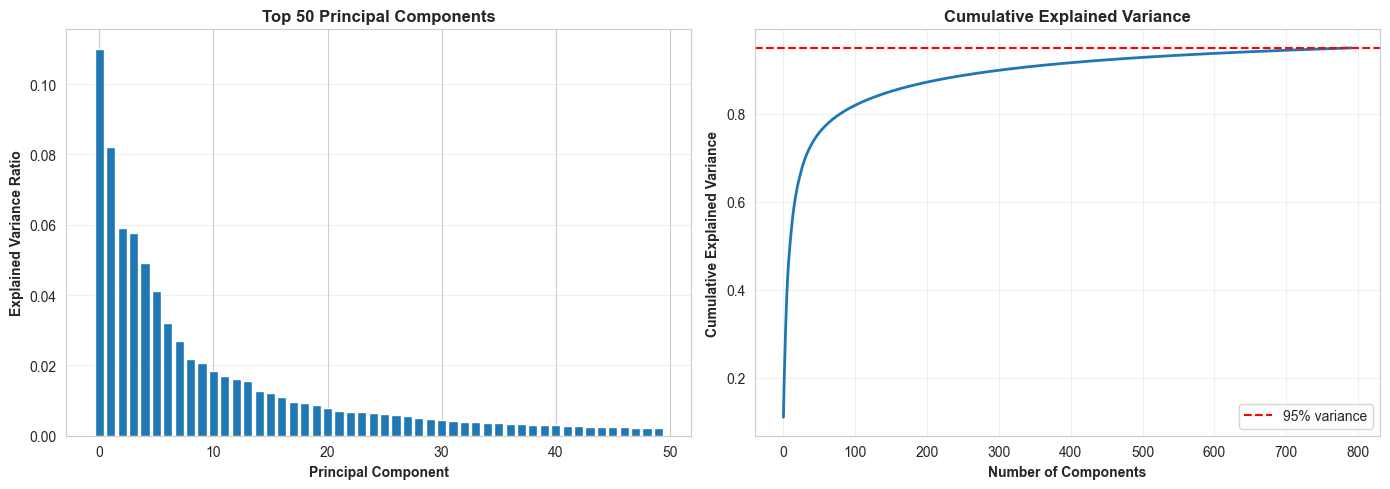

✓ PCA variance plot saved to: reports/figures/pca_variance.png


In [13]:
# Visualize PCA explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Explained variance ratio per component
n_components_to_plot = min(50, len(pca.explained_variance_ratio_))
axes[0].bar(range(n_components_to_plot), pca.explained_variance_ratio_[:n_components_to_plot])
axes[0].set_xlabel('Principal Component', fontweight='bold')
axes[0].set_ylabel('Explained Variance Ratio', fontweight='bold')
axes[0].set_title(f'Top {n_components_to_plot} Principal Components', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Cumulative explained variance
cumsum_var = np.cumsum(pca.explained_variance_ratio_)
axes[1].plot(cumsum_var, linewidth=2)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% variance')
axes[1].set_xlabel('Number of Components', fontweight='bold')
axes[1].set_ylabel('Cumulative Explained Variance', fontweight='bold')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'pca_variance.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ PCA variance plot saved to: reports/figures/pca_variance.png")

---
## 5. Train-Test Split & Cross-Validation Setup

Create both train-test split and cross-validation folds for comparison.

In [14]:
# Train-Test Split
test_size = 1 - config['data_strategy']['train_test_split_ratio']
random_state = config['reproducibility']['seed']
stratified = config['data_strategy']['stratified']

print("\n" + "="*60)
print("TRAIN-TEST SPLIT")
print("="*60)
print(f"Test size: {test_size*100:.0f}%")
print(f"Stratified: {stratified}")

# Split using PCA-transformed features
X_train, X_test, y_train, y_test = train_test_split(
    X_combined_pca, y_combined,
    test_size=test_size,
    random_state=random_state,
    stratify=y_combined if stratified else None
)

print(f"\nTrain set: {X_train.shape[0]} samples")
train_summary = dict(zip(*np.unique(y_train, return_counts=True)))
for cls in ['NORMAL', 'BACTERIA', 'VIRUS']:
    print(f"  {cls}: {train_summary.get(cls, 0)}")

print(f"\nTest set: {X_test.shape[0]} samples")
test_summary = dict(zip(*np.unique(y_test, return_counts=True)))
for cls in ['NORMAL', 'BACTERIA', 'VIRUS']:
    print(f"  {cls}: {test_summary.get(cls, 0)}")

logger.info(f"Train-test split: {X_train.shape[0]} train, {X_test.shape[0]} test")


TRAIN-TEST SPLIT
Test size: 20%
Stratified: True

Train set: 4185 samples
  NORMAL: 1079
  BACTERIA: 2030
  VIRUS: 1076

Test set: 1047 samples
  NORMAL: 270
  BACTERIA: 508
  VIRUS: 269
[INFO] Train-test split: 4185 train, 1047 test


In [15]:
# Cross-Validation Setup
cv_folds = config['data_strategy']['cv_folds']

print("\n" + "="*60)
print("CROSS-VALIDATION SETUP")
print("="*60)
print(f"Number of folds: {cv_folds}")
print(f"Stratified: {stratified}")

# Create stratified K-fold splitter
skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)

# Show fold statistics
print(f"\nFold statistics:")
for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_combined_pca, y_combined), 1):
    y_fold_train = y_combined[train_idx]
    y_fold_val = y_combined[val_idx]
    
    fold_train_summary = dict(zip(*np.unique(y_fold_train, return_counts=True)))
    fold_val_summary = dict(zip(*np.unique(y_fold_val, return_counts=True)))
    
    print(f"\n  Fold {fold_idx}:")
    print(f"    Train: {len(train_idx)} samples")
    for cls in ['NORMAL', 'BACTERIA', 'VIRUS']:
        print(f"      {cls}: {fold_train_summary.get(cls, 0)}")
    
    print(f"    Val: {len(val_idx)} samples")
    for cls in ['NORMAL', 'BACTERIA', 'VIRUS']:
        print(f"      {cls}: {fold_val_summary.get(cls, 0)}")

logger.info(f"Cross-validation setup: {cv_folds} folds")


CROSS-VALIDATION SETUP
Number of folds: 5
Stratified: True

Fold statistics:

  Fold 1:
    Train: 4185 samples
      NORMAL: 1079
      BACTERIA: 2030
      VIRUS: 1076
    Val: 1047 samples
      NORMAL: 270
      BACTERIA: 508
      VIRUS: 269

  Fold 2:
    Train: 4185 samples
      NORMAL: 1079
      BACTERIA: 2030
      VIRUS: 1076
    Val: 1047 samples
      NORMAL: 270
      BACTERIA: 508
      VIRUS: 269

  Fold 3:
    Train: 4186 samples
      NORMAL: 1079
      BACTERIA: 2031
      VIRUS: 1076
    Val: 1046 samples
      NORMAL: 270
      BACTERIA: 507
      VIRUS: 269

  Fold 4:
    Train: 4186 samples
      NORMAL: 1079
      BACTERIA: 2031
      VIRUS: 1076
    Val: 1046 samples
      NORMAL: 270
      BACTERIA: 507
      VIRUS: 269

  Fold 5:
    Train: 4186 samples
      NORMAL: 1080
      BACTERIA: 2030
      VIRUS: 1076
    Val: 1046 samples
      NORMAL: 269
      BACTERIA: 508
      VIRUS: 269
[INFO] Cross-validation setup: 5 folds


---
## 6. Save Preprocessed Data & Models

Save all preprocessed data, features, and transformers for future use.

In [17]:
# Create output directory
processed_dir = project_root / 'data' / 'processed'
processed_dir.mkdir(parents=True, exist_ok=True)

print("\n" + "="*60)
print("SAVING PROCESSED DATA")
print("="*60)

# Save train-test split data
np.save(processed_dir / 'X_train.npy', X_train)
np.save(processed_dir / 'X_test.npy', X_test)
np.save(processed_dir / 'y_train.npy', y_train)
np.save(processed_dir / 'y_test.npy', y_test)
print("✓ Train-test split data saved")

# Save full combined data for cross-validation
np.save(processed_dir / 'X_combined_pca.npy', X_combined_pca)
np.save(processed_dir / 'y_combined.npy', y_combined)
print("✓ Combined data saved (for cross-validation)")

# Save Dataset3 (reserved for hyperparameter tuning)
np.save(processed_dir / 'X_dataset3_pca.npy', X3_pca)
np.save(processed_dir / 'y_dataset3.npy', y_dataset3)
print("✓ Dataset3 saved (reserved for hyperparameter tuning)")

# Save PCA transformer
pca_path = project_root / 'models' / 'saved_models' / 'pca_transformer.pkl'
save_model(pca, pca_path, metadata={
    'n_components': int(pca.n_components_),
    'explained_variance_ratio': float(pca.explained_variance_ratio_.sum()),
    'original_dims': int(X_combined.shape[1]),
    'reduced_dims': int(X_combined_pca.shape[1])
})
print("✓ PCA transformer saved")

# Save preprocessing metadata
metadata = {
    'target_size': target_size,
    'color_mode': color_mode,
    'normalization': normalize,
    'feature_method': feature_method,
    'classification_mode': 'multiclass' if multiclass_mode else 'binary',
    'class_names': all_detected_classes,
    'num_classes': len(all_detected_classes),
    'pca_components': int(X_combined_pca.shape[1]),
    'train_samples': int(len(X_train)),
    'test_samples': int(len(X_test)),
    'dataset3_samples': int(len(X3_pca)),
    'random_seed': random_state
}
import json
with open(processed_dir / 'preprocessing_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=4)
print("✓ Preprocessing metadata saved")


class_info = {
    'class_names': all_detected_classes,
    'classification_mode': 'multiclass' if multiclass_mode else 'binary'
}

with open(processed_dir / 'class_info.json', 'w', encoding='utf-8') as f:
    json.dump(class_info, f, indent=4)

print("✓ Class info saved")

logger.info("All processed data saved successfully")
print(f"\n✓ All data saved to: {processed_dir}")


SAVING PROCESSED DATA
✓ Train-test split data saved
✓ Combined data saved (for cross-validation)
✓ Dataset3 saved (reserved for hyperparameter tuning)
✓ Model saved to c:\Users\MOULOUDIA\OneDrive - Epitech\Bureau\epitech\T-DEV-810-PAR_19\models\saved_models\pca_transformer.pkl
✓ PCA transformer saved
✓ Preprocessing metadata saved
✓ Class info saved
[INFO] All processed data saved successfully

✓ All data saved to: c:\Users\MOULOUDIA\OneDrive - Epitech\Bureau\epitech\T-DEV-810-PAR_19\data\processed


## 7. Summary & Next Steps

### Completed:
- ✓ Loaded all 3 datasets
- ✓ Extracted real multiclass labels from folder names + filenames
- ✓ Preprocessed images (resize, normalize)
- ✓ Extracted features (flattened/statistical/hybrid)
- ✓ Applied PCA (dimensionality reduction)
- ✓ Created stratified train-test split
- ✓ Setup stratified cross-validation folds
- ✓ Saved processed data, metadata, and transformers

### Data Summary:
- **Classification Mode:** Multiclass
- **Detected Classes:** NORMAL, BACTERIA, VIRUS
- **Training Set:** Ready for model training
- **Test Set:** Ready for evaluation
- **Cross-Validation:** 5-fold stratified setup
- **Dataset3:** Reserved for hyperparameter tuning

### Ready for Step 3: Baseline Modeling

In the next notebook (`03_Baseline_Modeling.ipynb`), we will:
1. Train baseline ML models (Logistic Regression, SVM, Random Forest, Gradient Boosting)
2. Compare train-test split vs cross-validation results
3. Evaluate using multiclass-aware metrics
4. Analyze class-level performance
5. Select best baseline model

---

**Key Files Generated:**
- `data/processed/X_train.npy` - Training features
- `data/processed/X_test.npy` - Test features
- `data/processed/y_train.npy` - Training labels
- `data/processed/y_test.npy` - Test labels
- `data/processed/X_combined_pca.npy` - Full data for CV
- `data/processed/y_combined.npy` - Full labels for CV
- `data/processed/X_dataset3_pca.npy` - Tuning dataset
- `data/processed/y_dataset3.npy` - Tuning labels
- `data/processed/preprocessing_metadata.json` - Preprocessing metadata
- `data/processed/class_info.json` - Classification setup
- `models/saved_models/pca_transformer.pkl` - PCA model
- `reports/figures/pca_variance.png` - PCA visualization
- `reports/pipeline.log` - Processing log

In [19]:
#verif des labels
print("\n" + "="*60)
print("FINAL LABEL CHECK")
print("="*60)

for name, labels in [
    ("Dataset1", y_dataset1),
    ("Dataset2", y_dataset2),
    ("Dataset3", y_dataset3),
    ("Combined", y_combined),
    ("Train", y_train),
    ("Test", y_test),
]:
    summary = dict(zip(*np.unique(labels, return_counts=True)))
    print(f"\n{name}:")
    for cls in ['NORMAL', 'BACTERIA', 'VIRUS']:
        print(f"  {cls}: {summary.get(cls, 0)}")


FINAL LABEL CHECK

Dataset1:
  NORMAL: 1341
  BACTERIA: 2530
  VIRUS: 1345

Dataset2:
  NORMAL: 8
  BACTERIA: 8
  VIRUS: 0

Dataset3:
  NORMAL: 234
  BACTERIA: 242
  VIRUS: 148

Combined:
  NORMAL: 1349
  BACTERIA: 2538
  VIRUS: 1345

Train:
  NORMAL: 1079
  BACTERIA: 2030
  VIRUS: 1076

Test:
  NORMAL: 270
  BACTERIA: 508
  VIRUS: 269
